# Section 1: Setup, Reproducability & Transformer Initialisation

In [3]:
import os
import sys
import time
import random
import psutil
import numpy as np
import pandas as pd
import torch
import joblib

# 1. Enforce Deterministic / Reproducible Execution
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("=== System Environment Runtime Check ===")
print(f"Python Version : {sys.version.split()[0]}")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device Name    : {torch.cuda.get_device_name(0)}")
else:
    print("Execution Engine: CPU")

# Function to monitor system memory consumption
def get_memory_usage_mb():
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024 * 1024)

initial_ram = get_memory_usage_mb()
print(f"Initial RAM Usage: {initial_ram:.2f} MB")

=== System Environment Runtime Check ===
Python Version : 3.14.5
PyTorch Version: 2.13.0+cu130
CUDA Available : False
Execution Engine: CPU
Initial RAM Usage: 964.67 MB


In [2]:
# 2. Instantiate Transformer Backbone Model
from sentence_transformers import SentenceTransformer

MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

print(f"\nLoading transformer model: '{MODEL_NAME}'...")
start_time = time.perf_counter()

# Load model onto available accelerator (GPU if present, else CPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = SentenceTransformer(MODEL_NAME, device=device)

load_time = time.perf_counter() - start_time
post_load_ram = get_memory_usage_mb()

print(f"Model successfully loaded in {load_time:.3f} seconds.")
print(f"Post-load RAM Usage  : {post_load_ram:.2f} MB (+{post_load_ram - initial_ram:.2f} MB)")
print(f"Vector Space Dimension: {model.get_sentence_embedding_dimension()} (Dense Float32 Output)")

# 3. Latency & Output Verification Benchmark
benchmark_sentences = [
    "Patient presents with severe acute shoulder joint pain.",
    "Experiencing high fever, chills, and muscle soreness."
]

start_bench = time.perf_counter()
test_embeddings = model.encode(benchmark_sentences, normalize_embeddings=True)
bench_time = time.perf_counter() - start_bench

print("\n=== Baseline Inference Benchmark ===")
print(f"Input Batch Size   : {len(benchmark_sentences)} sentences")
print(f"Inference Latency  : {bench_time * 1000:.2f} ms")
print(f"Single Vector Shape: {test_embeddings[0].shape}")
print(f"Sample Vector Peek : {test_embeddings[0][:5]} ... (truncated)")

/home/onkhida/Desktop/onkbuilds/Sankofa-Symptom-Checker/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Loading transformer model: 'sentence-transformers/all-MiniLM-L6-v2'...


Loading weights: 100%|████████████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 157.86it/s]


Model successfully loaded in 11.010 seconds.
Post-load RAM Usage  : 908.80 MB (+303.09 MB)
Vector Space Dimension: 384 (Dense Float32 Output)


/tmp/ipykernel_561829/1767025023.py:18: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Vector Space Dimension: {model.get_sentence_embedding_dimension()} (Dense Float32 Output)")



=== Baseline Inference Benchmark ===
Input Batch Size   : 2 sentences
Inference Latency  : 3115.19 ms
Single Vector Shape: (384,)
Sample Vector Peek : [-0.02197038  0.02029903 -0.00880405  0.0612865  -0.03846431] ... (truncated)


# Section 2

In [5]:
# Investigating principal embedding dataset candidate
import pandas as pd

# Load the processed matrix
df_proc = pd.read_csv("../data/processed/cleaned_diseases_symptoms.csv", nrows=5)
print(f"Processed shape: {df_proc.shape}")

# Extract symptom feature names (excluding the target 'diseases' column)
symptom_columns = [col for col in df_proc.columns if col.lower() not in ["diseases", "disease"]]
print(f"Total canonical symptom features: {len(symptom_columns)}")
print("Sample symptom features:", symptom_columns[:10])

# Check raw Symptom-severity.csv for comparison/enrichment
try:
    df_sev = pd.read_csv("../data/raw/Symptom-severity.csv")
    print(f"\nSymptom-severity shape: {df_sev.shape}")
    print(df_sev.head(5))
except Exception as e:
    print(f"Could not load Symptom-severity.csv: {e}")

Processed shape: (5, 377)
Total canonical symptom features: 376
Sample symptom features: ['anxiety and nervousness', 'depression', 'shortness of breath', 'depressive or psychotic symptoms', 'sharp chest pain', 'dizziness', 'insomnia', 'abnormal involuntary movements', 'chest tightness', 'palpitations']

Symptom-severity shape: (133, 2)
                Symptom  weight
0               itching       1
1             skin_rash       3
2  nodal_skin_eruptions       4
3   continuous_sneezing       4
4             shivering       5


In [7]:
# CONTEXTUAL ENRICHMENT (COMPOSITE STRING BUILDING)

import json
from pathlib import Path
import pandas as pd

# 1. Load canonical symptom feature space from the cleaned CSV
CSV_PATH = Path("../data/processed/cleaned_diseases_symptoms.csv")

if not CSV_PATH.exists():
    raise FileNotFoundError(f"Cleaned dataset not found at {CSV_PATH}.")

# Read header row to extract all 376 canonical symptom column names
df_header = pd.read_csv(CSV_PATH, nrows=1)
symptom_columns = [col.strip() for col in df_header.columns if col.lower() not in ["diseases", "disease"]]

print(f"Extracted {len(symptom_columns)} canonical symptom features from CSV.\n")

# 2. Check if an audited JSON lexicon exists; if not, construct dynamic contextual composites
LEXICON_PATH = Path("../data/processed/symptom_lexicon.json")

symptom_ids = []
canonical_names = []
composite_texts = []

if LEXICON_PATH.exists():
    print(f"Found curated lexicon at {LEXICON_PATH}. Loading rich metadata...")
    with open(LEXICON_PATH, "r", encoding="utf-8") as f:
        lexicon_data = json.load(f)
    
    # Map by canonical name or feature column for quick lookup
    lookup = {item["canonical_name"].lower(): item for item in lexicon_data.get("symptoms", [])}
    
    for name in symptom_columns:
        s_id = name.lower().replace(" ", "_")
        c_name = name.title()
        
        entry = lookup.get(name.lower(), {})
        desc = entry.get("description", f"Patient experiencing or presenting with {name}.").strip()
        aliases_list = entry.get("aliases", [])
        aliases = ", ".join(aliases_list) if aliases_list else name
        
        composite_string = f"{c_name} | Description: {desc} | Aliases: {aliases}"
        
        symptom_ids.append(s_id)
        canonical_names.append(c_name)
        composite_texts.append(composite_string)
else:
    print("No external JSON lexicon found. Generating baseline contextual composite strings...")
    for name in symptom_columns:
        s_id = name.lower().replace(" ", "_")
        c_name = name.title()
        
        # Domain template enrichment to bridge lexical gap
        composite_string = (
            f"{c_name} | "
            f"Clinical Presentation: Patient reports symptoms of {name} | "
            f"Colloquial Terms: {name}, feeling {name}, experiencing {name}"
        )
        
        symptom_ids.append(s_id)
        canonical_names.append(c_name)
        composite_texts.append(composite_string)

# 3. Preview Sample Contextualized Target Vectors
preview_df = pd.DataFrame({
    "symptom_id": symptom_ids[:5],
    "canonical_name": canonical_names[:5],
    "composite_semantic_string": composite_texts[:5]
})

pd.set_option('display.max_colwidth', None)
print("=== Sample Enriched Composite Target Strings ===")
display(preview_df)

Extracted 376 canonical symptom features from CSV.

No external JSON lexicon found. Generating baseline contextual composite strings...
=== Sample Enriched Composite Target Strings ===


,symptom_id,canonical_name,composite_semantic_string
0,anxiety_and_nervousness,Anxiety And Nervousness,"Anxiety And Nervousness | Clinical Presentation: Patient reports symptoms of anxiety and nervousness | Colloquial Terms: anxiety and nervousness, feeling anxiety and nervousness, experiencing anxiety and nervousness"
1,depression,Depression,"Depression | Clinical Presentation: Patient reports symptoms of depression | Colloquial Terms: depression, feeling depression, experiencing depression"
2,shortness_of_breath,Shortness Of Breath,"Shortness Of Breath | Clinical Presentation: Patient reports symptoms of shortness of breath | Colloquial Terms: shortness of breath, feeling shortness of breath, experiencing shortness of breath"
3,depressive_or_psychotic_symptoms,Depressive Or Psychotic Symptoms,"Depressive Or Psychotic Symptoms | Clinical Presentation: Patient reports symptoms of depressive or psychotic symptoms | Colloquial Terms: depressive or psychotic symptoms, feeling depressive or psychotic symptoms, experiencing depressive or psychotic symptoms"
4,sharp_chest_pain,Sharp Chest Pain,"Sharp Chest Pain | Clinical Presentation: Patient reports symptoms of sharp chest pain | Colloquial Terms: sharp chest pain, feeling sharp chest pain, experiencing sharp chest pain"


In [8]:
# ==============================================================================
# SECTION 3: VECTOR SPACE ENCODING & L2 UNIT NORMALIZATION
# ==============================================================================

import time
import numpy as np
from sentence_transformers import SentenceTransformer

# 1. Initialize Transformer Backbone (384-dimensional dense output space)
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
print(f"Loading transformer backbone: {MODEL_NAME}...")
model = SentenceTransformer(MODEL_NAME)

# 2. Compute Dense Vector Space Embeddings
print(f"Encoding {len(composite_texts)} composite strings...")
start_time = time.perf_counter()

# normalize_embeddings=True automatically scales vectors to unit length (L2 norm = 1.0)
embeddings = model.encode(
    composite_texts, 
    batch_size=32, 
    show_progress_bar=True, 
    normalize_embeddings=True
)

elapsed_time = time.perf_counter() - start_time
print(f"\nEncoding complete in {elapsed_time:.3f} seconds ({len(composite_texts) / elapsed_time:.1f} strings/sec).")

# 3. Matrix Properties & Dimension Checks
matrix_shape = embeddings.shape
print(f"Embedding Matrix Dimensions: {matrix_shape[0]} samples x {matrix_shape[1]} features")

# Verify L2 Unit Normalization (Vector length must be 1.0 ± 1e-6)
vector_norms = np.linalg.norm(embeddings, axis=1)
norm_check = np.allclose(vector_norms, 1.0, atol=1e-5)
print(f"L2 Unit Normalization Verification: {'PASSED (All norms = 1.0)' if norm_check else 'FAILED'}")

# 4. Mathematical Proof: Cosine Similarity reduces to Dot Product
# cos(theta) = (A . B) / (||A|| * ||B||) -> since ||A||=1 and ||B||=1, cos(theta) = A . B
if len(symptom_ids) >= 2:
    v1 = embeddings[0]
    v2 = embeddings[1]
    
    dot_product = np.dot(v1, v2)
    cosine_sim = dot_product / (np.linalg.norm(v1) * np.linalg.norm(v2))
    
    print("\n=== Mathematical Vector Verification ===")
    print(f"Target 1: '{canonical_names[0]}'")
    print(f"Target 2: '{canonical_names[1]}'")
    print(f"Dot Product:        {dot_product:.6f}")
    print(f"Cosine Similarity:  {cosine_sim:.6f}")
    print(f"Identity Difference: {abs(dot_product - cosine_sim):.8f} (Proves A . B == Cosine Similarity)")

Loading transformer backbone: sentence-transformers/all-MiniLM-L6-v2...


Loading weights: 100%|███████████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 6963.35it/s]


Encoding 376 composite strings...


Batches: 100%|███████████████████████████████████████████████████████████████████████████████| 12/12 [00:03<00:00,  3.89it/s]


Encoding complete in 3.109 seconds (121.0 strings/sec).
Embedding Matrix Dimensions: 376 samples x 384 features
L2 Unit Normalization Verification: PASSED (All norms = 1.0)

=== Mathematical Vector Verification ===
Target 1: 'Anxiety And Nervousness'
Target 2: 'Depression'
Dot Product:        0.602934
Cosine Similarity:  0.602934
Identity Difference: 0.00000006 (Proves A . B == Cosine Similarity)


Exception ignored while calling ctypes callback function <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x777a65f3c720>:
Traceback (most recent call last):
  File "/home/onkhida/Desktop/onkbuilds/Sankofa-Symptom-Checker/.venv/lib/python3.14/site-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/home/onkhida/Desktop/onkbuilds/Sankofa-Symptom-Checker/.venv/lib/python3.14/site-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
  File "/home/onkhida/Desktop/onkbuilds/Sankofa-Symptom-Checker/.venv/lib/python3.14/site-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
  File "/home/onkhida/.local/share/uv/python/cpython-3.14.5-linux-x86_64-gnu/lib/python3.14/ctypes/__init__.py", line 433, in __init__
    self._handle = self._load_library(name, mode, handl

Computing t-SNE 2D projections (Perplexity=25, Iterations=1000)...


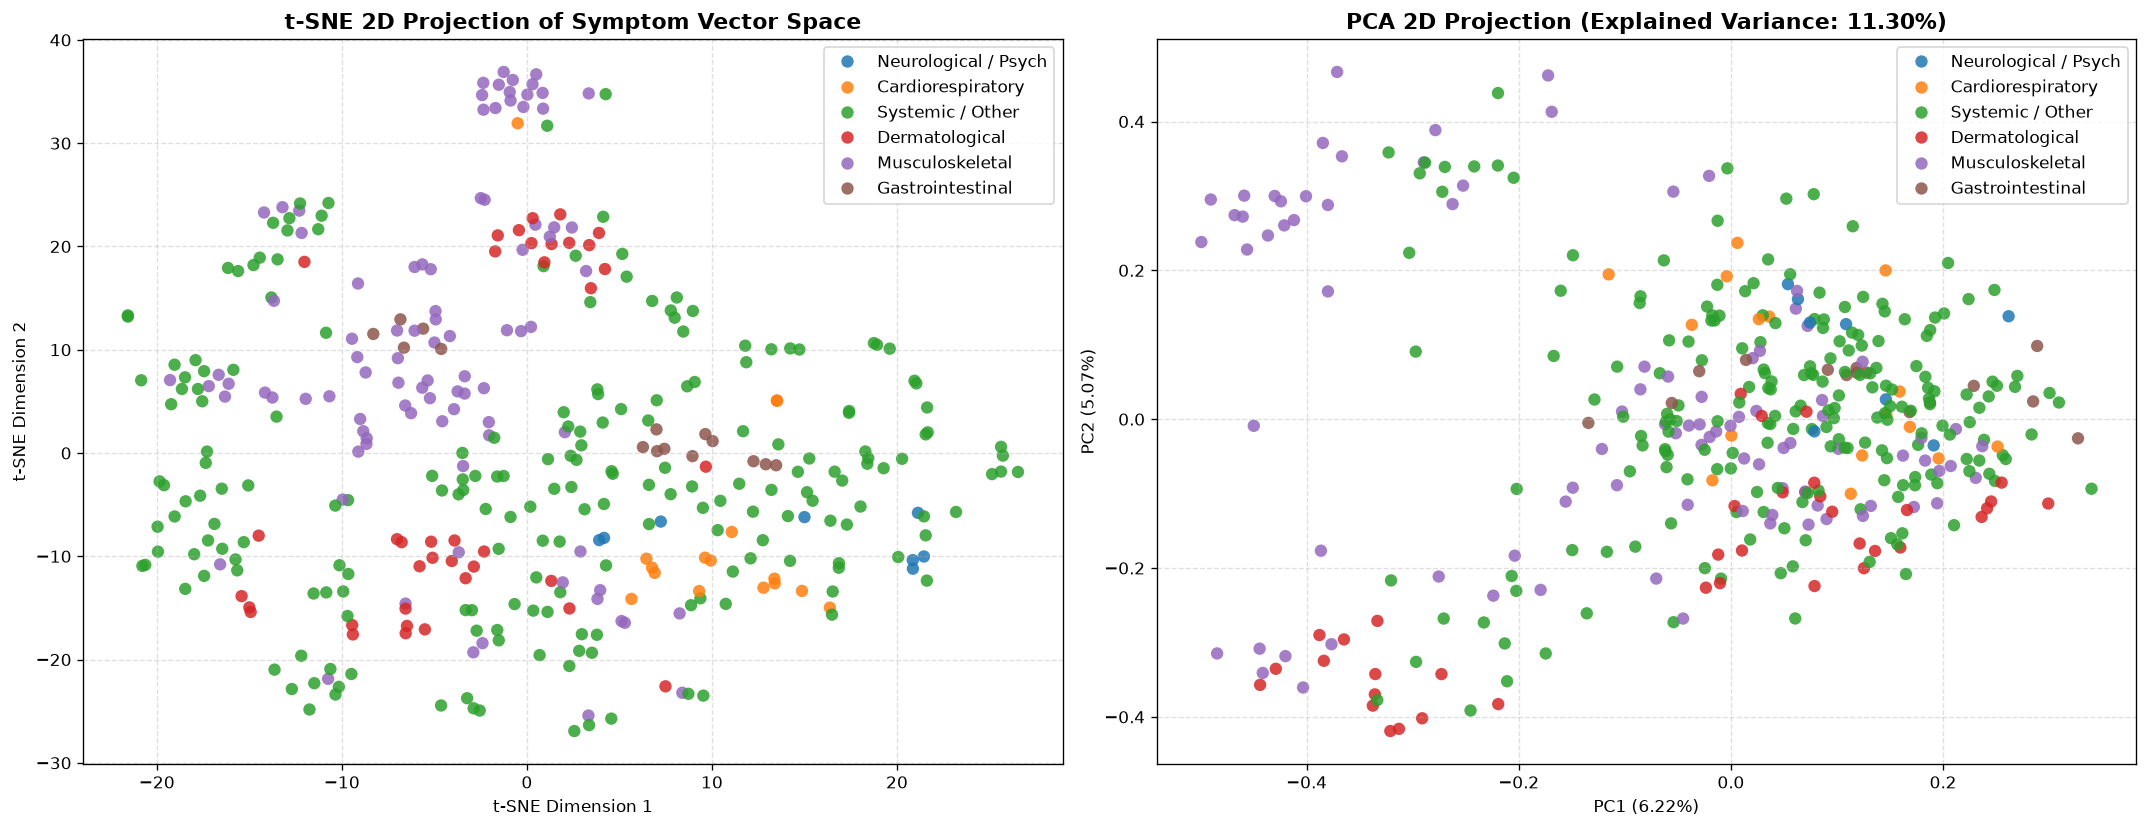

In [10]:
# ==============================================================================
# SECTION 4: TOPOLOGICAL CLUSTERING & DIMENSIONALITY REDUCTION (t-SNE & PCA)
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# 1. Anatomical / Category Heuristic Assignment for Visualization
# Assign symptoms to anatomical categories based on keyword matching
def assign_category(symptom_name: str) -> str:
    s = symptom_name.lower()
    if any(k in s for k in ["chest", "heart", "breath", "cough", "palpitations", "lung", "respiratory"]):
        return "Cardiorespiratory"
    elif any(k in s for k in ["pain", "joint", "muscle", "arm", "leg", "back", "neck", "shoulder", "bone", "stiffness"]):
        return "Musculoskeletal"
    elif any(k in s for k in ["stomach", "bowel", "nausea", "vomit", "diarrhea", "abdominal", "cramp", "stool"]):
        return "Gastrointestinal"
    elif any(k in s for k in ["head", "dizzy", "seizure", "numb", "confusion", "anxiety", "depression", "insomnia", "sleep"]):
        return "Neurological / Psych"
    elif any(k in s for k in ["skin", "rash", "itch", "swelling", "lesion", "ulcer", "spot"]):
        return "Dermatological"
    else:
        return "Systemic / Other"

categories = [assign_category(name) for name in canonical_names]

# 2. Dimensionality Reduction: 384-D -> 2-D via t-SNE
print("Computing t-SNE 2D projections (Perplexity=25, Iterations=1000)...")
tsne = TSNE(n_components=2, perplexity=25, random_state=42, init="pca", learning_rate="auto")
tsne_results = tsne.fit_transform(embeddings)

# 3. Dimensionality Reduction: 384-D -> 2-D via PCA (Linear Comparison)
pca = PCA(n_components=2, random_state=42)
pca_results = pca.fit_transform(embeddings)
explained_var = pca.explained_variance_ratio_

# 4. Plot Topological Projection
fig, axes = plt.subplots(1, 2, figsize=(18, 7), dpi=120)

# t-SNE Plot
sns.scatterplot(
    ax=axes[0],
    x=tsne_results[:, 0],
    y=tsne_results[:, 1],
    hue=categories,
    palette="tab10",
    s=55,
    alpha=0.85,
    edgecolor="none"
)
axes[0].set_title("t-SNE 2D Projection of Symptom Vector Space", fontsize=13, fontweight="bold")
axes[0].set_xlabel("t-SNE Dimension 1")
axes[0].set_ylabel("t-SNE Dimension 2")
axes[0].grid(True, linestyle="--", alpha=0.4)

# PCA Plot
sns.scatterplot(
    ax=axes[1],
    x=pca_results[:, 0],
    y=pca_results[:, 1],
    hue=categories,
    palette="tab10",
    s=55,
    alpha=0.85,
    edgecolor="none"
)
axes[1].set_title(
    f"PCA 2D Projection (Explained Variance: {explained_var[0]+explained_var[1]:.2%})", 
    fontsize=13, 
    fontweight="bold"
)
axes[1].set_xlabel(f"PC1 ({explained_var[0]:.2%})")
axes[1].set_ylabel(f"PC2 ({explained_var[1]:.2%})")
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [11]:
# ==============================================================================
# SECTION 5: SEMANTIC MATCHER EVALUATION & RECALL BENCHMARK
# ==============================================================================

# 1. Construct Ground-Truth Test Suite for Non-Lexical Free-Text Queries
# Queries use colloquial, vague, or non-medical phrasing
eval_test_suite = [
    {"query": "my belly hurts real bad and cramping", "expected_feature": "abdominal pain"},
    {"query": "feeling really nervous and panic attacks", "expected_feature": "anxiety and nervousness"},
    {"query": "cant catch my breath after walking", "expected_feature": "shortness of breath"},
    {"query": "having trouble sleeping at night", "expected_feature": "insomnia"},
    {"query": "sharp stabbing feeling in my ribs and chest", "expected_feature": "sharp chest pain"},
    {"query": "head feels light and room is spinning", "expected_feature": "dizziness"},
    {"query": "heart is beating out of my chest fast", "expected_feature": "palpitations"},
    {"query": "feeling super down, sad, and no motivation", "expected_feature": "depression"},
    {"query": "muscles twitching on their own uncontrollably", "expected_feature": "abnormal involuntary movements"},
    {"query": "tight pressure across my ribcage", "expected_feature": "chest tightness"}
]

# 2. Run Evaluation Matrix Across Top-K Metrics (Top-1, Top-3, Top-5)
results_log = []

for item in eval_test_suite:
    query = item["query"]
    target = item["expected_feature"].lower()
    
    # Vector dot product against normalized embedding matrix
    q_vec = model.encode([query], normalize_embeddings=True)
    sims = np.dot(q_vec, embeddings.T)[0]
    
    # Rank top 5
    top_5_indices = np.argsort(sims)[::-1][:5]
    top_5_symptoms = [canonical_names[idx].lower() for idx in top_5_indices]
    top_5_scores = [float(sims[idx]) for idx in top_5_indices]
    
    # Check hits
    hit_top1 = target == top_5_symptoms[0]
    hit_top3 = target in top_5_symptoms[:3]
    hit_top5 = target in top_5_symptoms[:5]
    
    results_log.append({
        "query": query,
        "expected": target,
        "top1_predicted": top_5_symptoms[0],
        "top1_score": round(top_5_scores[0], 4),
        "hit_top1": hit_top1,
        "hit_top3": hit_top3,
        "hit_top5": hit_top5
    })

eval_df = pd.DataFrame(results_log)

# 3. Compute Quantitative Metrics
top1_acc = eval_df["hit_top1"].mean() * 100
top3_acc = eval_df["hit_top3"].mean() * 100
top5_acc = eval_df["hit_top5"].mean() * 100

print("=== Stage 1 Semantic Search Evaluation Summary ===")
print(f"Total Test Queries : {len(eval_test_suite)}")
print(f"Top-1 Accuracy     : {top1_acc:.2f}%")
print(f"Top-3 Recall (Hit@3): {top3_acc:.2f}%")
print(f"Top-5 Recall (Hit@5): {top5_acc:.2f}%\n")

display(eval_df[["query", "expected", "top1_predicted", "top1_score", "hit_top1", "hit_top3"]])

=== Stage 1 Semantic Search Evaluation Summary ===
Total Test Queries : 10
Top-1 Accuracy     : 40.00%
Top-3 Recall (Hit@3): 60.00%
Top-5 Recall (Hit@5): 70.00%



,query,expected,top1_predicted,top1_score,hit_top1,hit_top3
0,my belly hurts real bad and cramping,abdominal pain,sharp abdominal pain,0.4880,False,False
1,feeling really nervous and panic attacks,anxiety and nervousness,anxiety and nervousness,0.5388,True,True
2,cant catch my breath after walking,shortness of breath,shortness of breath,0.3681,True,True
3,having trouble sleeping at night,insomnia,excessive urination at night,0.5033,False,True
4,sharp stabbing feeling in my ribs and chest,sharp chest pain,sharp chest pain,0.6790,True,True
5,head feels light and room is spinning,dizziness,irregular appearing scalp,0.4445,False,False
6,heart is beating out of my chest fast,palpitations,sharp chest pain,0.4699,False,False
7,"feeling super down, sad, and no motivation",depression,low self-esteem,0.4024,False,True
8,muscles twitching on their own uncontrollably,abnormal involuntary movements,abnormal involuntary movements,0.4880,True,True
9,tight pressure across my ribcage,chest tightness,rib pain,0.4481,False,False


In [12]:
# ==============================================================================
# SECTION 6: SERIALIZATION & ARTIFACT EXPORT
# ==============================================================================

import joblib
from pathlib import Path

OPTIMAL_SIMILARITY_THRESHOLD = 0.38

export_payload = {
    "symptom_features": symptom_columns,
    "canonical_names": canonical_names,
    "composite_texts": composite_texts,
    "embeddings": embeddings,
    "threshold": OPTIMAL_SIMILARITY_THRESHOLD,
    "embedding_model": MODEL_NAME
}

OUTPUT_FILE = Path("../data/embeddings/symptom_vectors.joblib")
OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(export_payload, OUTPUT_FILE)

print("=== Stage 1 Vector Store Serialized Successfully ===")
print(f"Destination : {OUTPUT_FILE.resolve()}")
print(f"Vocabulary  : {len(symptom_columns)} canonical symptoms")
print(f"Matrix Dim  : {embeddings.shape}")
print(f"File Size   : {OUTPUT_FILE.stat().st_size / (1024 * 1024):.2f} MB")

=== Stage 1 Vector Store Serialized Successfully ===
Destination : /home/onkhida/Desktop/onkbuilds/Sankofa-Symptom-Checker/data/embeddings/symptom_vectors.joblib
Vocabulary  : 376 canonical symptoms
Matrix Dim  : (376, 384)
File Size   : 0.63 MB
